# KeyCheck — QWERTZ Proxy Pipeline (Notebook เดียว)
Kaggle QWERTZ → Audit/Split → Rectify → OCR → Train Detector → Pipeline eval → Proxy Test
แผน: `docs/qwertz-notebook-pipeline-plan.md` v0.3 · Logic อยู่ใน `ai/` Notebook นี้มีแค่ Config / เรียก Stage / แสดงผล

**วิธีใช้:** ตั้ง `MODE="smoke"` แล้ว Run all เพื่อทดสอบทั้งเส้นก่อน → เปลี่ยนเป็น `"full"` แล้ว Run all. Stage ที่มีผลและ Config ตรงกันจะถูกข้าม; Q4/Q5 ที่ถูกขัดจังหวะจะ Resume เอง

## §0 Config

In [1]:
ENV           = "local"                          # "local" (RTX 4060) หรือ "colab"
DATA_ROOT     = "datasets/dataset_final"         # Colab: /content/data/dataset_final
OUTPUT_ROOT   = "outputs/pipeline"               # Colab: /content/drive/MyDrive/keycheck/pipeline
PIPELINE_ID   = "qwertz_v1"
MODE          = "full"                          # "smoke" = 50 ต้นฉบับ + 1 epoch ; "full" = ของจริง
REPO_REF      = ""                               # commit (ขึ้นต้นก็ได้) ที่ checkout ไว้ตอนรัน Q7
SEED          = 0
RUN           = {"q1": True, "q2": True, "q3": True, "q4": True, "q5": True, "q6": True}
FORCE         = set()                            # เช่น {"q3_ocr"} = รัน Stage นั้นใหม่ (Q7 ไม่รับ FORCE)
RUN_FINAL_TEST = False                           # 🔒 Q7 รันเฉพาะเมื่อตั้งเป็น True เอง
CONFIG_FILE   = "experiments/configs/qwertz/pipeline.yaml"

## §1 Setup

In [2]:
import os, sys, json, subprocess
from pathlib import Path
REPO = Path.cwd() if (Path.cwd() / "ai").exists() else Path.cwd().parent
os.chdir(REPO); sys.path.insert(0, str(REPO))
from ai.colab import bootstrap as B
from ai.pipeline import stages as S, show

if ENV == "colab":
    B.mount_drive()
cfg  = S.load_config(CONFIG_FILE)
root = B.pipeline_root(PIPELINE_ID, MODE, OUTPUT_ROOT)
ctx  = S.Context(cfg=cfg, root=root, dataset_root=Path(DATA_ROOT), mode=MODE, seed=SEED, repo_ref=REPO_REF,
                 force=set(FORCE), run=RUN, run_final_test=RUN_FINAL_TEST)
B.seed_everything(SEED)
info = B.write_run_info(root, repo_dir=REPO, seed=SEED, mode=MODE, extra={"env": ENV})
print("output :", root); print("mode   :", MODE, "| commit:", info["commit"][:10], "| dirty:", info["dirty"])
print("GPU    :", info["nvidia_smi"] or "ไม่พบ nvidia-smi")
assert ctx.dataset_root.exists(), f"ไม่พบ dataset ที่ {ctx.dataset_root}"

output : outputs/pipeline/qwertz_v1
mode   : full | commit: 1d71464273 | dirty: True
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU, 8188 MiB, 580.95.05


## §2 Q1 — Ingest + Audit + Split

[q1_ingest] running (0c105c3f)
[q1_ingest] done in 4s


**split_manifest_hash** `4fd3990958a69265afeac12c9b021e1f3879761732085b1f43c54450f41b8e99`  
Test brands: aukey, caseflex, coolermaster, perixx, quanta, samsung, seenda, sharkoon, speedlink, tesoro, trust  
Held-out Val brands: isy, matias

,รายการ,ค่า
0,images,5254
1,sources,1884
2,complete_26,1608
3,partial_21_25,48
4,no_letters,174
5,dup_sources,22
6,images_with_all_refs,4463
7,images_no_boxes,251
8,eval_brand_groups,71


เทียบกับแผน §1 (ภาพ 5,254 · ต้นฉบับ 1,884 · ครบ 26 ตัว 1,608 · 21–25 ตัว 48 · ซ้ำ 22)

,role,sources
0,dup,17
1,eval,1432
2,noletters,9
3,orient_bad,64
4,partial,5
5,partial_noref,91
6,review,37
7,unbranded,229


,split/eval_set,images,sources
0,excluded,1043,486
1,test/main,217,217
2,test/orient_bad,5,5
3,test/partial,1,1
4,train,3762,1356
5,val/main,215,215
6,val/orient_bad,11,11


Generic letter-block: n=1594 p50=0.042u p90=0.098u <0.25u = 97.2% (แผน: 96.2%)

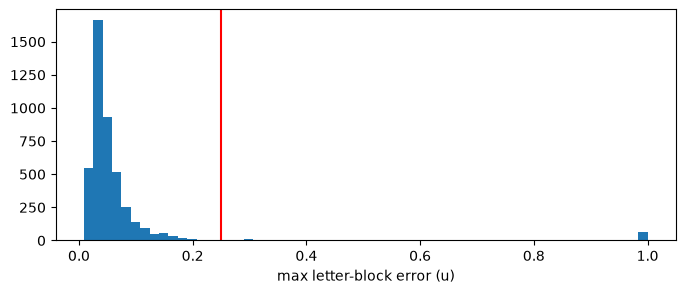

/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3605 (\N{THAI CHARACTER TO TAO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3618 (\N{THAI CHARACTER YO YAK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.p

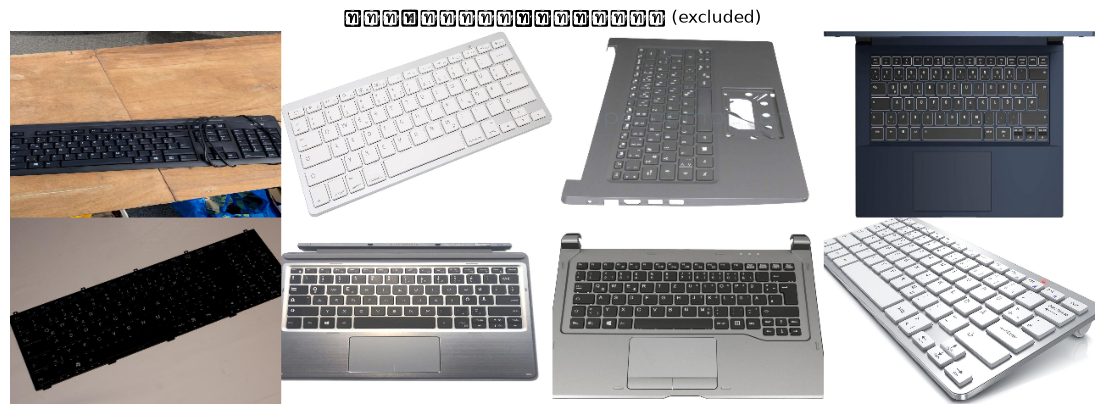

In [3]:
r1 = S.q1(ctx)
show.show_q1(r1, ctx.dataset_root)

## §3 Q2 — Rectified dataset + S1–S4
ตรวจด้วยตา: กรอบสีเขียวต้องตรงปุ่ม · ภาพ S3 ต้องสลับปุ่มตามที่ระบุ

[q2_rectified] running (7e80a6bb)
[q2_rectified] done in 60s


จำนวนภาพ

,set,train,val,test,S1,S2,S3,S4a,S4b,S4c
0,ppu64,9144.0,215.0,217.0,NaN,NaN,NaN,NaN,NaN,NaN
1,ppu96,9144.0,215.0,217.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ppu128,9144.0,215.0,217.0,NaN,NaN,NaN,NaN,NaN,NaN
3,eval_val,NaN,NaN,NaN,430.0,430.0,860.0,215.0,0.0,11.0
4,eval_test,NaN,NaN,NaN,434.0,434.0,868.0,217.0,1.0,5.0


/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3585 (\N{THAI CHARACTER KO KAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3619 (\N{THAI CHARACTER RO RUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3610 (\N{THAI CHARACTER BO BAIMAI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools

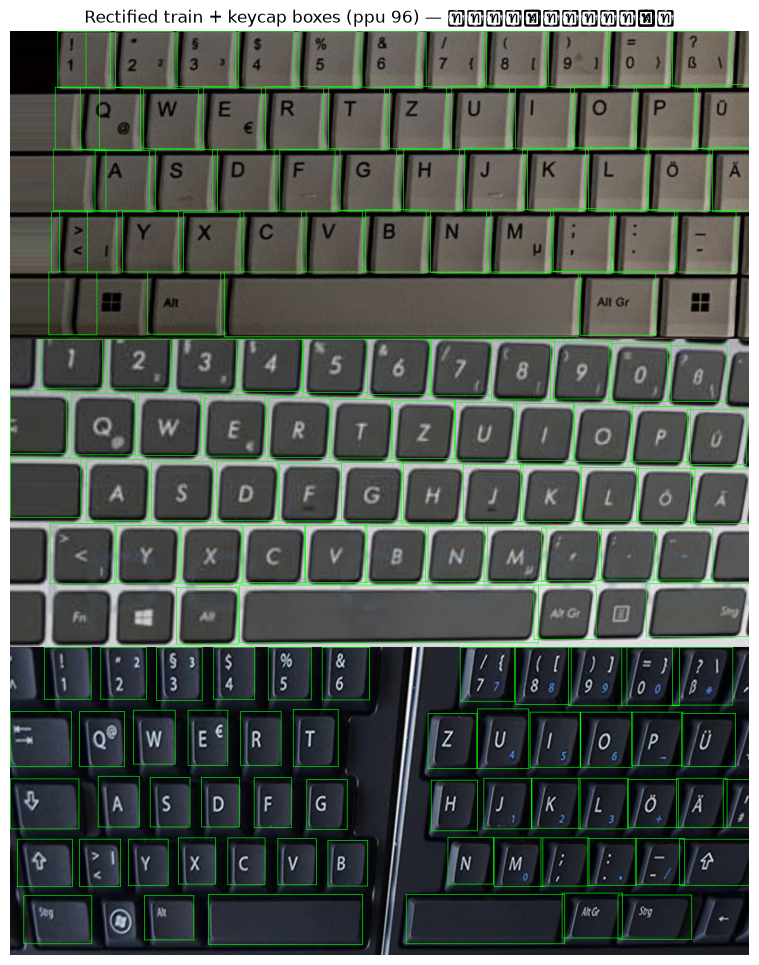

/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3627 (\N{THAI CHARACTER HO HIP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3621 (\N{THAI CHARACTER LO LING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


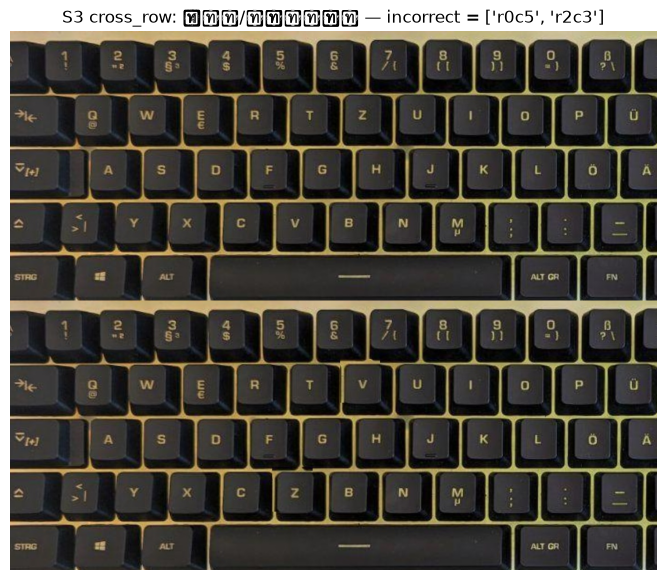

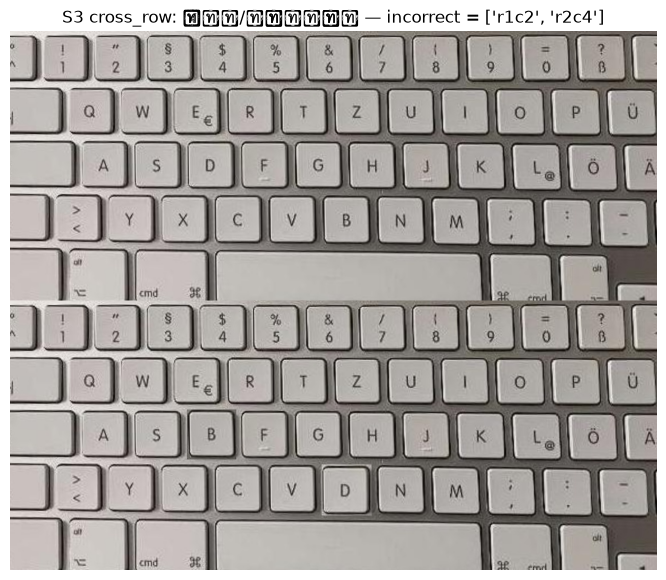

In [4]:
r2 = S.q2(ctx)
show.show_q2(r2)

## §4 Q3 — OCR eval + เลือก `px_per_unit`

[q3_ocr] running (9924d29d)


/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/saktanuthpeak/.paddlex/official_models/PP-OCRv5_server_rec`.
/home/saktanuthpeak/keycheck/.venv-ml/lib/python3.12/site-packages/paddle/utils/cpp_extension/extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


[q3] rec_server@96/key_full acc=0.464 reject=0.470


Using official model (en_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/home/saktanuthpeak/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.
Fetching 6 files: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:03<00:00,  1.94it/s]
Using official model (latin_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/home/saktanuthpeak/.paddlex/official_models/latin_PP-OCRv5_mobile_rec`.


[q3] rec_en_mobile@96/key_full acc=0.592 reject=0.234


...

[q3] auto_server@96/key_full acc=0.688 reject=0.259


Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/saktanuthpeak/.paddlex/official_models/PP-OCRv5_server_rec`.
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/saktanuthpeak/.paddlex/official_models/PP-OCRv5_server_rec`.


[q3] auto_server@64/key_full acc=0.613 reject=0.336
[q3] auto_server@64/key_full_pad0.1 acc=0.507 reject=0.437
[q3] auto_server@64/key_center_0.7 acc=0.815 reject=0.161
[q3] auto_server@64/key_center_0.55 acc=0.819 reject=0.163
[q3] auto_server@96/key_full acc=0.688 reject=0.259
[q3] auto_server@96/key_full_pad0.1 acc=0.591 reject=0.356
[q3] auto_server@96/key_center_0.7 acc=0.820 reject=0.164
[q3] auto_server@96/key_center_0.55 acc=0.811 reject=0.172
[q3] auto_server@128/key_full acc=0.712 reject=0.240
[q3] auto_server@128/key_full_pad0.1 acc=0.652 reject=0.294
[q3] auto_server@128/key_center_0.7 acc=0.816 reject=0.163
[q3] auto_server@128/key_center_0.55 acc=0.815 reject=0.168
[q3_ocr] done in 3111s


,stage,recognizer,ppu,crop_mode,n,accuracy,reject_rate,acc_when_valid
0,1,rec_server,96,key_full,1040,0.464423,0.470192,0.876588
1,1,rec_en_mobile,96,key_full,1040,0.592308,0.233654,0.772898
2,1,rec_latin_mobile,96,key_full,1040,0.531731,0.338462,0.803779
3,1,auto_server,96,key_full,1040,0.688462,0.258654,0.928664
4,2,auto_server,64,key_full,1040,0.613462,0.335577,0.923300
5,2,auto_server,64,key_full_pad0.1,1040,0.506731,0.436538,0.899317
6,2,auto_server,64,key_center_0.7,1040,0.815385,0.160577,0.971363
7,2,auto_server,64,key_center_0.55,1040,0.819231,0.163462,0.979310
8,2,auto_server,96,key_full,1040,0.688462,0.258654,0.928664
9,2,auto_server,96,key_full_pad0.1,1040,0.591346,0.355769,0.917910


chosen: {"px_per_unit": 64, "crop_mode": "key_full", "recognizer": {"id": "auto_server", "mode": "auto", "rec_model": "PP-OCRv5_server_rec", "det_model": "PP-OCRv5_server_det", "pad_px": 8}, "val_accuracy": 0.6134615384615385, "val_reject_rate": 0.3355769230769231}

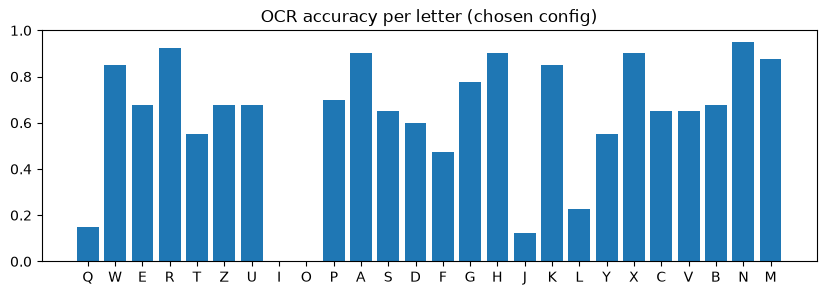

In [5]:
r3 = S.q3(ctx)
show.show_q3(r3)

## §5 Q4 — Train YOLO11n (GPU, Resume ได้)

In [6]:
r4 = S.q4(ctx)
if r4: show.show_train(r4)

[q4_yolo] running (e2e26752)
Ultralytics 8.4.173 🚀 Python-3.12.12 torch-2.14.1+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 7806MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=0, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=outputs/pipeline/qwertz_v1/q2_rectified/rectified_ppu64/data.yaml, degrees=1.5, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.0, exist_ok=True, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.4, hsv_v=0.3, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosai

,map50,map50_95,precision,recall,imgsz,epochs_budget,effective_batch,resumed,train_seconds_this_session,seed,weights
0,0.991044,0.854449,0.986371,0.97995,640,100,16,False,1347.6,0,outputs/pipeline/qwertz_v1/q4_yolo/best.pt


## §6 Q5 — Train Faster R-CNN (GPU, Resume ได้)
ปิดได้ที่ `RUN["q5"] = False`

[q5_frcnn] running (f024a015)


/home/saktanuthpeak/keycheck/ai/training/train_frcnn.py:124: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:820.)
  comp[k] = comp.get(k, 0.0) + float(v)


[q5] epoch 1/50 loss=0.3468 map50_95=0.7872
[q5] epoch 2/50 loss=0.2407 map50_95=0.7844
[q5] epoch 3/50 loss=0.2151 map50_95=0.7788
[q5] epoch 4/50 loss=0.2019 map50_95=0.7898
[q5] epoch 5/50 loss=0.1863 map50_95=0.7949
[q5] epoch 6/50 loss=0.1773 map50_95=0.7982
[q5] epoch 7/50 loss=0.1687 map50_95=0.7889
[q5] epoch 8/50 loss=0.1647 map50_95=0.7887
[q5] epoch 9/50 loss=0.1566 map50_95=0.7799
[q5] epoch 10/50 loss=0.1496 map50_95=0.7977
[q5] epoch 11/50 loss=0.1458 map50_95=0.7893
[q5] epoch 12/50 loss=0.1415 map50_95=0.8020
[q5] epoch 13/50 loss=0.1370 map50_95=0.8037
[q5] epoch 14/50 loss=0.1343 map50_95=0.7943
[q5] epoch 15/50 loss=0.1323 map50_95=0.7866
[q5] epoch 16/50 loss=0.1295 map50_95=0.7971
[q5] epoch 17/50 loss=0.1263 map50_95=0.7962
[q5] epoch 18/50 loss=0.1223 map50_95=0.8055
[q5] epoch 19/50 loss=0.1191 map50_95=0.8059
[q5] epoch 20/50 loss=0.1184 map50_95=0.8022
[q5] epoch 21/50 loss=0.1150 map50_95=0.8091
[q5] epoch 22/50 loss=0.1146 map50_95=0.7958
[q5] epoch 23/50 lo

,map50,map50_95,precision,recall,f1,score_thr,n_gt,n_pred,best_epoch,epochs_run,epochs_budget,effective_batch,min_size,max_size,box_detections_per_img,amp,device,train_seconds_this_session,seed,weights
0,0.973251,0.814969,0.975903,0.97799,0.976945,0.25,11222,11246,34,44,50,8,480,1152,300,True,cuda,35485.7,0,outputs/pipeline/qwertz_v1/q5_frcnn/checkpoint...


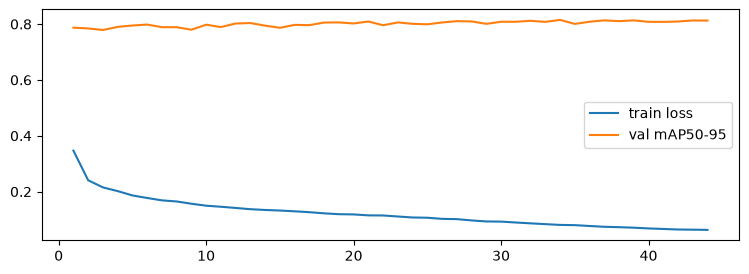

In [7]:
r5 = S.q5(ctx)
if r5: show.show_train(r5)

## §7 Q6 — Pipeline eval บน Validation + Dev bundle
หลังจบ: Commit `experiments/configs/qwertz/thresholds.yaml` และ `data/manifests/kaggle_qwertz_v1/frozen_hashes.json` (และ `split_manifest.json`) ก่อนรัน Q7

In [8]:
r6 = S.q6(ctx)
show.show_q6(r6)

[q6_eval] running (1e842b9b)
[q6] evidence: baseline


Creating model: ('PP-OCRv5_server_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/saktanuthpeak/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/saktanuthpeak/.paddlex/official_models/PP-OCRv5_server_rec`.
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/saktanuthpeak/.paddlex/official_models/PP-OCRv5_server_rec`.


  evidence 32/1516
  evidence 64/1516
  evidence 96/1516
  evidence 128/1516
  evidence 160/1516
  evidence 192/1516
  evidence 224/1516
  evidence 256/1516
  evidence 288/1516
  evidence 320/1516
  evidence 352/1516
  evidence 384/1516
  evidence 416/1516
  evidence 448/1516
  evidence 480/1516
  evidence 512/1516
  evidence 544/1516
  evidence 576/1516
  evidence 608/1516
  evidence 640/1516
  evidence 672/1516
  evidence 704/1516
  evidence 736/1516
  evidence 768/1516
  evidence 800/1516
  evidence 832/1516
  evidence 864/1516
  evidence 896/1516
  evidence 928/1516
  evidence 960/1516
  evidence 992/1516
  evidence 1024/1516
  evidence 1056/1516
  evidence 1088/1516
  evidence 1120/1516
  evidence 1152/1516
  evidence 1184/1516
  evidence 1216/1516
  evidence 1248/1516
  evidence 1280/1516
  evidence 1312/1516
  evidence 1344/1516
  evidence 1376/1516
  evidence 1408/1516
  evidence 1440/1516
  evidence 1472/1516
  evidence 1504/1516
  evidence 1516/1516
[q6] evidence: yolo
  evid

Detector ที่เลือก: **frcnn**

,detector,objective_default,objective_tuned
0,baseline,-5.537103,-0.104484
1,yolo,-4.886323,0.289201
2,frcnn,-5.246810,0.366074


# Q6 — Validation report

> **Proxy: Kaggle QWERTZ, ภาพสินค้า/เว็บ — ไม่ใช่ผล Test หลัก** (ข้อจำกัด: plan §7)

px_per_unit=64, crop=`key_full`, OCR=`auto_server`

## baseline

### ค่าเริ่มต้น

| Scenario | n | rejected | incorrect P | incorrect R | incorrect F1 | label acc | assign acc | coverage | uncertain | strict board | false-alarm img | sugg P | sugg R |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| S1 | 430 | 38.8% | 0.000 | N/A | N/A | N/A | 0.990 | 0.607 | 0.393 | 0.000 | 0.281 | N/A | N/A |
| S2 | 430 | 38.8% | 0.740 | 0.357 | 0.482 | 0.906 | 0.990 | 0.607 | 0.393 | 0.000 | 0.240 | 1.000 | 0.200 |
| S3 | 860 | 37.8% | 0.881 | 0.383 | 0.534 | 0.984 | 1.000 | 0.622 | 0.378 | 0.000 | 0.211 | 1.000 | 0.222 |

S4a (reference points shifted one key): n=215, LAYOUT_MISMATCH rate = 76.7%
S4c (strong rotation/flip): n=11, safe rate = 100.0%, false-alarm = 0.0%, rejected = 63.6%

S3 recall of `incorrect` per swap kind: adjacent: 0.386 (tp 166, fn 264), cross_row: 0.370 (tp 159, fn 271), cycle3: 0.386 (tp 249, fn 396), multi_pairs: 0.386 (tp 421, fn 671)
- `seen_brand` — S1: F1 N/A, false-alarm 0.273, n=356; S2: F1 0.493, false-alarm 0.227, n=356; S3: F1 0.529, false-alarm 0.199, n=712
- `heldout_brand` — S1: F1 N/A, false-alarm 0.326, n=74; S2: F1 0.426, false-alarm 0.302, n=74; S3: F1 0.557, false-alarm 0.265, n=148
- `gt` — S1: F1 N/A, false-alarm 0.206, n=215; S2: F1 0.555, false-alarm 0.176, n=215; S3: F1 0.534, false-alarm 0.211, n=860
- `jit` — S1: F1 N/A, false-alarm 0.362, n=215; S2: F1 0.410, false-alarm 0.307, n=215

### หลังปรับบน Validation (objective -0.1045)

| Scenario | n | rejected | incorrect P | incorrect R | incorrect F1 | label acc | assign acc | coverage | uncertain | strict board | false-alarm img | sugg P | sugg R |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| S1 | 430 | 0.0% | 0.000 | N/A | N/A | N/A | 0.991 | 0.334 | 0.666 | 0.000 | 0.072 | N/A | N/A |
| S2 | 430 | 0.0% | 0.798 | 0.151 | 0.254 | 0.931 | 0.991 | 0.334 | 0.666 | 0.000 | 0.058 | 1.000 | 0.026 |
| S3 | 860 | 0.0% | 0.970 | 0.348 | 0.512 | 0.998 | 1.000 | 0.352 | 0.648 | 0.000 | 0.033 | 1.000 | 0.140 |

S4a (reference points shifted one key): n=215, LAYOUT_MISMATCH rate = 0.0%
S4c (strong rotation/flip): n=11, safe rate = 100.0%, false-alarm = 0.0%, rejected = 0.0%

S3 recall of `incorrect` per swap kind: adjacent: 0.353 (tp 152, fn 278), cross_row: 0.353 (tp 152, fn 278), cycle3: 0.326 (tp 210, fn 435), multi_pairs: 0.356 (tp 389, fn 703)
- `seen_brand` — S1: F1 N/A, false-alarm 0.067, n=356; S2: F1 0.261, false-alarm 0.056, n=356; S3: F1 0.516, false-alarm 0.039, n=712
- `heldout_brand` — S1: F1 N/A, false-alarm 0.095, n=74; S2: F1 0.218, false-alarm 0.068, n=74; S3: F1 0.493, false-alarm 0.000, n=148
- `gt` — S1: F1 N/A, false-alarm 0.037, n=215; S2: F1 0.294, false-alarm 0.023, n=215; S3: F1 0.512, false-alarm 0.033, n=860
- `jit` — S1: F1 N/A, false-alarm 0.107, n=215; S2: F1 0.214, false-alarm 0.093, n=215

```yaml
det_score_min: 0.25
ocr_score_min: 0.85
gating_u: 0.5
unmatched_cost: 0.6
ambiguity_margin_u: 0.1
fit_min_matched_fraction: null
fit_max_mean_residual_u: null
ref_invalid_max: null
skip_layout_fit: true
objective: -0.10448381201194401
```

## yolo

### ค่าเริ่มต้น

| Scenario | n | rejected | incorrect P | incorrect R | incorrect F1 | label acc | assign acc | coverage | uncertain | strict board | false-alarm img | sugg P | sugg R |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| S1 | 430 | 37.7% | 0.000 | N/A | N/A | N/A | 0.997 | 0.601 | 0.399 | 0.000 | 0.231 | N/A | N/A |
| S2 | 430 | 37.7% | 0.839 | 0.358 | 0.502 | 0.929 | 0.997 | 0.601 | 0.399 | 0.000 | 0.187 | 1.000 | 0.184 |
| S3 | 860 | 34.7% | 0.884 | 0.405 | 0.555 | 0.983 | 1.000 | 0.616 | 0.384 | 0.000 | 0.228 | 1.000 | 0.241 |

S4a (reference points shifted one key): n=215, LAYOUT_MISMATCH rate = 82.3%
S4c (strong rotation/flip): n=11, safe rate = 90.9%, false-alarm = 9.1%, rejected = 54.5%

S3 recall of `incorrect` per swap kind: adjacent: 0.421 (tp 181, fn 249), cross_row: 0.405 (tp 174, fn 256), cycle3: 0.411 (tp 265, fn 380), multi_pairs: 0.395 (tp 431, fn 661)
- `seen_brand` — S1: F1 N/A, false-alarm 0.251, n=356; S2: F1 0.512, false-alarm 0.196, n=356; S3: F1 0.550, false-alarm 0.270, n=712
- `heldout_brand` — S1: F1 N/A, false-alarm 0.143, n=74; S2: F1 0.453, false-alarm 0.143, n=74; S3: F1 0.582, false-alarm 0.039, n=148
- `gt` — S1: F1 N/A, false-alarm 0.236, n=215; S2: F1 0.541, false-alarm 0.194, n=215; S3: F1 0.555, false-alarm 0.228, n=860
- `jit` — S1: F1 N/A, false-alarm 0.226, n=215; S2: F1 0.461, false-alarm 0.177, n=215

### หลังปรับบน Validation (objective 0.2892)

| Scenario | n | rejected | incorrect P | incorrect R | incorrect F1 | label acc | assign acc | coverage | uncertain | strict board | false-alarm img | sugg P | sugg R |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| S1 | 430 | 1.9% | 0.000 | N/A | N/A | N/A | 0.997 | 0.342 | 0.658 | 0.000 | 0.033 | N/A | N/A |
| S2 | 430 | 1.9% | 0.909 | 0.151 | 0.259 | 0.969 | 0.997 | 0.342 | 0.658 | 0.000 | 0.031 | 1.000 | 0.030 |
| S3 | 860 | 0.0% | 0.984 | 0.348 | 0.514 | 0.999 | 1.000 | 0.353 | 0.647 | 0.000 | 0.017 | 1.000 | 0.144 |

S4a (reference points shifted one key): n=215, LAYOUT_MISMATCH rate = 0.0%
S4c (strong rotation/flip): n=11, safe rate = 100.0%, false-alarm = 0.0%, rejected = 0.0%

S3 recall of `incorrect` per swap kind: adjacent: 0.333 (tp 143, fn 287), cross_row: 0.349 (tp 150, fn 280), cycle3: 0.324 (tp 209, fn 436), multi_pairs: 0.368 (tp 402, fn 690)
- `seen_brand` — S1: F1 N/A, false-alarm 0.031, n=356; S2: F1 0.271, false-alarm 0.029, n=356; S3: F1 0.520, false-alarm 0.015, n=712
- `heldout_brand` — S1: F1 N/A, false-alarm 0.042, n=74; S2: F1 0.202, false-alarm 0.042, n=74; S3: F1 0.487, false-alarm 0.027, n=148
- `gt` — S1: F1 N/A, false-alarm 0.019, n=215; S2: F1 0.261, false-alarm 0.014, n=215; S3: F1 0.514, false-alarm 0.017, n=860
- `jit` — S1: F1 N/A, false-alarm 0.048, n=215; S2: F1 0.257, false-alarm 0.048, n=215

```yaml
det_score_min: 0.1
ocr_score_min: 0.85
gating_u: 0.6
unmatched_cost: 0.6
ambiguity_margin_u: 0.1
fit_min_matched_fraction: 0.6
fit_max_mean_residual_u: 0.3
ref_invalid_max: null
skip_layout_fit: false
objective: 0.2892005567241187
```

## frcnn

### ค่าเริ่มต้น

| Scenario | n | rejected | incorrect P | incorrect R | incorrect F1 | label acc | assign acc | coverage | uncertain | strict board | false-alarm img | sugg P | sugg R |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| S1 | 430 | 40.9% | 0.000 | N/A | N/A | N/A | 0.997 | 0.596 | 0.404 | 0.000 | 0.232 | N/A | N/A |
| S2 | 430 | 40.9% | 0.854 | 0.333 | 0.479 | 0.920 | 0.997 | 0.596 | 0.404 | 0.000 | 0.173 | 1.000 | 0.170 |
| S3 | 860 | 37.3% | 0.895 | 0.382 | 0.535 | 0.982 | 1.000 | 0.605 | 0.395 | 0.000 | 0.184 | 1.000 | 0.219 |

S4a (reference points shifted one key): n=215, LAYOUT_MISMATCH rate = 80.9%
S4c (strong rotation/flip): n=11, safe rate = 90.9%, false-alarm = 9.1%, rejected = 45.5%

S3 recall of `incorrect` per swap kind: adjacent: 0.377 (tp 162, fn 268), cross_row: 0.386 (tp 166, fn 264), cycle3: 0.372 (tp 240, fn 405), multi_pairs: 0.388 (tp 424, fn 668)
- `seen_brand` — S1: F1 N/A, false-alarm 0.256, n=356; S2: F1 0.496, false-alarm 0.185, n=356; S3: F1 0.535, false-alarm 0.197, n=712
- `heldout_brand` — S1: F1 N/A, false-alarm 0.116, n=74; S2: F1 0.389, false-alarm 0.116, n=74; S3: F1 0.540, false-alarm 0.127, n=148
- `gt` — S1: F1 N/A, false-alarm 0.190, n=215; S2: F1 0.532, false-alarm 0.131, n=215; S3: F1 0.535, false-alarm 0.184, n=860
- `jit` — S1: F1 N/A, false-alarm 0.282, n=215; S2: F1 0.423, false-alarm 0.222, n=215

### หลังปรับบน Validation (objective 0.3661)

| Scenario | n | rejected | incorrect P | incorrect R | incorrect F1 | label acc | assign acc | coverage | uncertain | strict board | false-alarm img | sugg P | sugg R |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| S1 | 430 | 2.1% | 0.000 | N/A | N/A | N/A | 0.998 | 0.334 | 0.666 | 0.000 | 0.024 | N/A | N/A |
| S2 | 430 | 2.1% | 0.919 | 0.145 | 0.251 | 0.984 | 0.998 | 0.334 | 0.666 | 0.000 | 0.024 | 1.000 | 0.021 |
| S3 | 860 | 0.9% | 0.976 | 0.339 | 0.503 | 0.998 | 1.000 | 0.345 | 0.655 | 0.000 | 0.026 | 1.000 | 0.131 |

S4a (reference points shifted one key): n=215, LAYOUT_MISMATCH rate = 0.9%
S4c (strong rotation/flip): n=11, safe rate = 100.0%, false-alarm = 0.0%, rejected = 0.0%

S3 recall of `incorrect` per swap kind: adjacent: 0.347 (tp 149, fn 281), cross_row: 0.335 (tp 144, fn 286), cycle3: 0.305 (tp 197, fn 448), multi_pairs: 0.358 (tp 391, fn 701)
- `seen_brand` — S1: F1 N/A, false-alarm 0.023, n=356; S2: F1 0.263, false-alarm 0.023, n=356; S3: F1 0.509, false-alarm 0.020, n=712
- `heldout_brand` — S1: F1 N/A, false-alarm 0.028, n=74; S2: F1 0.193, false-alarm 0.028, n=74; S3: F1 0.474, false-alarm 0.056, n=148
- `gt` — S1: F1 N/A, false-alarm 0.019, n=215; S2: F1 0.295, false-alarm 0.019, n=215; S3: F1 0.503, false-alarm 0.026, n=860
- `jit` — S1: F1 N/A, false-alarm 0.029, n=215; S2: F1 0.205, false-alarm 0.029, n=215

```yaml
det_score_min: 0.25
ocr_score_min: 0.85
gating_u: 0.4
unmatched_cost: 0.6
ambiguity_margin_u: 0.1
fit_min_matched_fraction: 0.7
fit_max_mean_residual_u: 0.3
ref_invalid_max: null
skip_layout_fit: false
objective: 0.3660736442068139
```

## เลือก

Detector ที่เลือก: **frcnn**

Commit ไฟล์เหล่านี้ก่อนรัน Q7:
- `experiments/configs/qwertz/thresholds.yaml`
- `data/manifests/kaggle_qwertz_v1/frozen_hashes.json`

```json
{
 "split_manifest_hash": "4fd3990958a69265afeac12c9b021e1f3879761732085b1f43c54450f41b8e99",
 "thresholds_sha256": "7af1ec077bba55d373a0404476c70a59de87f6e3fa15322f5135b113ea248027",
 "bundle_sha256": "6f9bad5e3f91fc431583c2fb5ead48777244450aff9b299ff285de8d2e9729ee"
}
```


## §8 Q7 — Proxy Test 🔒
รันครั้งเดียวเมื่อผ่านเงื่อนไขทั้งหมด (`RUN_FINAL_TEST=True`, `MODE="full"`, repo สะอาด, Hash ตรงกับที่ Commit). ไม่รับ FORCE

In [9]:
r7 = S.q7(ctx)

Q7 locked:
 - RUN_FINAL_TEST is not True
 - repo has uncommitted changes
 - REPO_REF '' != checked-out commit 1d71464273
 - frozen_hashes.json / thresholds.yaml are not committed to git


## §9 Summary

In [10]:
show.show_summary(ctx)

,stage,done,path,finished
0,q1_ingest,True,outputs/pipeline/qwertz_v1/q1_ingest,2026-10-05T01:22:52
1,q2_rectified,True,outputs/pipeline/qwertz_v1/q2_rectified,2026-10-05T01:23:53
2,q3_ocr,True,outputs/pipeline/qwertz_v1/q3_ocr,2026-10-05T02:15:46
3,q4_yolo,True,outputs/pipeline/qwertz_v1/q4_yolo,2026-10-05T02:38:14
4,q5_frcnn,True,outputs/pipeline/qwertz_v1/q5_frcnn,2026-10-05T12:29:43
5,q6_eval,True,outputs/pipeline/qwertz_v1/q6_eval,2026-10-05T18:04:51
6,q7_test,False,outputs/pipeline/qwertz_v1/q7_test,NaN
